In [53]:
import numpy as np
import pandas as pd
from datetime import timedelta

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n=1000

In [54]:
df = pd.DataFrame({
    "order_id": [f"O{i}" for i in range (1,n+1)],
    "customer_id": np.random.choice( [f"C{i}" for i in range(1,201)] , n),
    "order_date": pd.to_datetime("2021-01-01")  + pd.to_timedelta(np.random.randint(0 , 365 , n) , unit="D"),
    "ship_date": pd.to_datetime("2021-01-01") + pd.to_timedelta(np.random.randint(0 , 370 , n) , unit="D"),
    "product_id": np.random.choice([f"P{i}" for i in range(1,501)] , n),
    "category": np.random.choice(["Electronics" , "Clothing" , "Furniture" , "Toys" , "Books"] , n),
    "price": np.random.randint(200 , 50000 , n),
    "quantity": np.random.randint(1 , 5 , n),
    "payment_type": np.random.choice(["Credit Card" , "Debit Card" , "UPI" , "COD"] , n),
    "city": np.random.choice([f"City_{i}" for i in range(1 , 51)] , n),
    "review_text": np.random.choice(["Great Product", "Bad Service", "Loved It", "Not Good", "Excellent", "Okay Experience"] , n)
})

# target variable

df["returned"] = ( ( df["price"] < 5000 ).astype(int) + ( df["category"] == "Clothing" ).astype(int) ) > 0
df["returned"] = df["returned"].astype(int)
df.head()

,order_id,customer_id,order_date,ship_date,product_id,category,price,quantity,payment_type,city,review_text,returned
0,O1,C103,2021-08-24,2021-09-03,P76,Electronics,40372,4,UPI,City_12,Great Product,0
1,O2,C180,2021-03-24,2021-05-05,P344,Books,33922,3,COD,City_30,Great Product,0
2,O3,C93,2021-02-11,2021-09-25,P495,Books,10825,2,Credit Card,City_40,Great Product,0
3,O4,C15,2021-04-11,2021-05-11,P424,Books,1829,4,Debit Card,City_7,Loved It,1
4,O5,C107,2021-01-06,2021-08-25,P294,Furniture,11173,3,Credit Card,City_32,Excellent,0


In [55]:
df["order_value"] = df["price"] * df["quantity"]

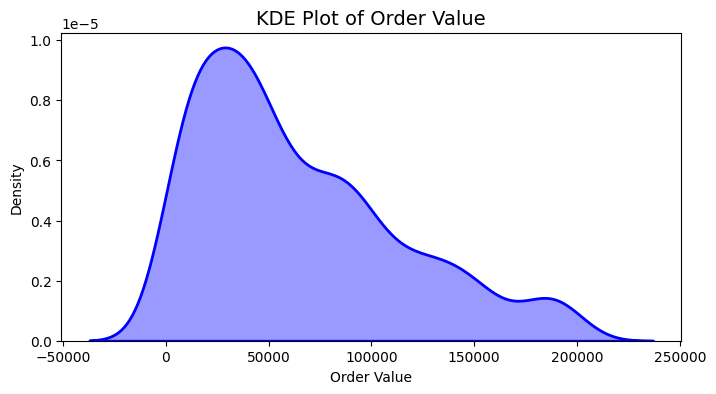

In [56]:
plt.figure(figsize=(8,4))

sns.kdeplot(df["order_value"] , fill=True , color="blue" , alpha=0.4 , linewidth=2)

plt.title("KDE Plot of Order Value" , fontsize=14)

plt.xlabel("Order Value" , fontsize=10)
plt.ylabel("Density" , fontsize=10)
plt.show()

### Let's try Transformation to remove order_value skewness

In [57]:
# Lof Transformation


df["order_value_log"] = np.log(df["order_value"])

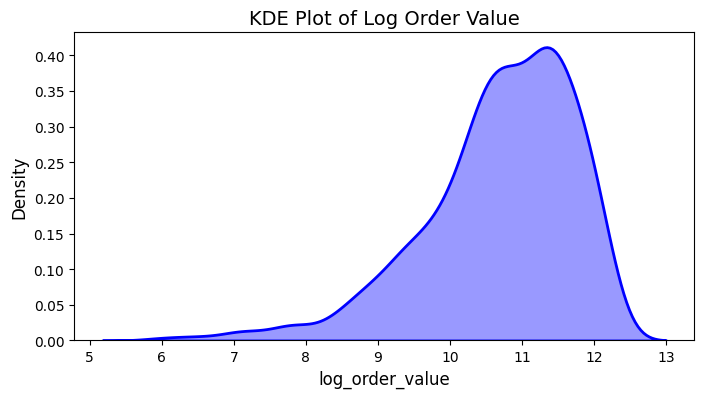

In [58]:
plt.figure(figsize=(8,4))

sns.kdeplot(df["order_value_log"] , fill=True , color="blue" , alpha=0.4 , linewidth=2)
plt.title("KDE Plot of Log Order Value", fontsize=14)
plt.xlabel("log_order_value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.show()

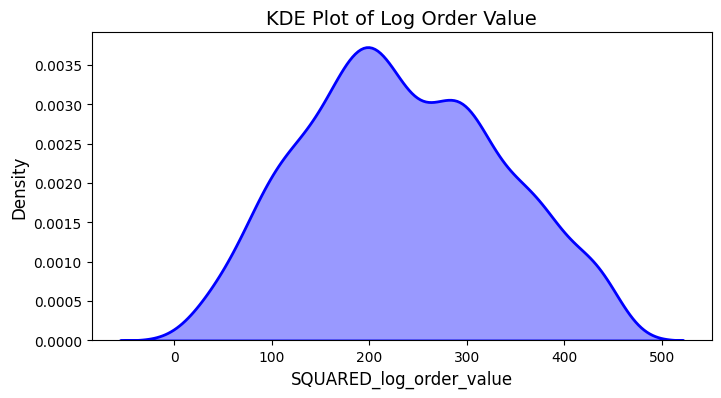

In [59]:
df["order_value_SQRT"] = np.sqrt(df["order_value"])

plt.figure(figsize=(8,4))

sns.kdeplot(df["order_value_SQRT"] , fill=True , color="blue" , alpha=0.4 , linewidth=2)
plt.title("KDE Plot of Log Order Value", fontsize=14)
plt.xlabel("SQUARED_log_order_value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.show()

### Date/Time Features

In [60]:
df["order_dow"] = df["order_date"].dt.dayofweek
df["order_month"] = df["order_date"].dt.month
df["ship_delay"] = (df["ship_date"] - df["order_date"]).dt.days

# Cyclical feature encoding trick
df["order_month_sin"] = np.sin( 2* np.pi * df["order_month"]/12 )
df["order_month_cos"] = np.sin( 2 * np.pi * df["order_month"]/12 )

df[["order_date" , "ship_date" , "order_dow" , "order_month" , "ship_delay"]].head()

,order_date,ship_date,order_dow,order_month,ship_delay
0,2021-08-24,2021-09-03,1,8,10
1,2021-03-24,2021-05-05,2,3,42
2,2021-02-11,2021-09-25,3,2,226
3,2021-04-11,2021-05-11,6,4,30
4,2021-01-06,2021-08-25,2,1,231


#### Customer-Level Aggregates

In [61]:
customer_agg = df.groupby("customer_id").agg({
    'order_value' : ["mean" , "sum" , "count"],
    "returned" : "mean"
}).reset_index()
customer_agg.head()

customer_id   order_value                returned
                       mean     sum count      mean
0          C1  55077.250000  440618     8  0.125000
1         C10  42903.000000   85806     2  0.000000
2        C100  52156.500000  208626     4  0.250000
3        C101  72450.714286  507155     7  0.285714
4        C102  87999.000000  175998     2  0.000000

In [62]:
customer_agg.columns

MultiIndex([('customer_id',      ''),
            ('order_value',  'mean'),
            ('order_value',   'sum'),
            ('order_value', 'count'),
            (   'returned',  'mean')],
           )

In [63]:
customer_agg.columns = ["customer_id" , "cust_avg_order_val" , "cust_total_spent" , "cust_order_freq" , "cust_return_rate"]

In [64]:
customer_agg.head()

,customer_id,cust_avg_order_val,cust_total_spent,cust_order_freq,cust_return_rate
0,C1,55077.250000,440618,8,0.125000
1,C10,42903.000000,85806,2,0.000000
2,C100,52156.500000,208626,4,0.250000
3,C101,72450.714286,507155,7,0.285714
4,C102,87999.000000,175998,2,0.000000


In [65]:
df = df.merge(customer_agg , on="customer_id" , how="left")

In [66]:
df[["customer_id" , "cust_avg_order_val" , "cust_order_freq" , "cust_return_rate"]].head()

,customer_id,cust_avg_order_val,cust_order_freq,cust_return_rate
0,C103,114718.166667,6,0.333333
1,C180,57371.333333,6,0.166667
2,C93,36753.857143,7,0.428571
3,C15,55240.857143,7,0.142857
4,C107,45192.000000,3,0.000000


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            1000 non-null   str           
 1   customer_id         1000 non-null   str           
 2   order_date          1000 non-null   datetime64[us]
 3   ship_date           1000 non-null   datetime64[us]
 4   product_id          1000 non-null   str           
 5   category            1000 non-null   str           
 6   price               1000 non-null   int32         
 7   quantity            1000 non-null   int32         
 8   payment_type        1000 non-null   str           
 9   city                1000 non-null   str           
 10  review_text         1000 non-null   str           
 11  returned            1000 non-null   int64         
 12  order_value         1000 non-null   int32         
 13  order_value_log     1000 non-null   float64       
 14  orde

In [68]:
cat_agg = df.groupby("category").agg({
    "order_value":"mean",
    "returned":"mean",
    "order_id":"count"
}).reset_index()
cat_agg.columns = ["category","cat_avg_order_val","cat_return_rate","cat_order_count"]

df = df.merge(cat_agg , on="category" , how="left")

In [69]:
city_counts = df["city"].value_counts()
df["city_freq"] = df["city"].map(city_counts)

In [70]:
df[["city" , "city_freq"]].head()

,city,city_freq
0,City_12,28
1,City_30,18
2,City_40,20
3,City_7,22
4,City_32,14


#### Text Feature For Review

In [77]:
df["review_len"] = df["review_text"].str.len()
df["review_word_count"] = df["review_text"].str.split().str.len()
df[["review_text" , "review_len" , "review_word_count"]].head()

,review_text,review_len,review_word_count
0,Great Product,13,2
1,Great Product,13,2
2,Great Product,13,2
3,Loved It,8,2
4,Excellent,9,1


#### Intraction Feature

In [82]:
# This feature captures the interaction between order_value and ship_delay.
# Instead of letting the model "discover" the nonlinear interaction between order value and ship delay, you give it directly.

df["val_per_delay"] = df["order_value"] / (df["ship_delay"]+1) # plus 1 esiliye kiya ki agar koi prodcut me delay na ho to wo Zero hoga esilye one add kiya
df[["order_value","ship_delay","val_per_delay"]].head()

,order_value,ship_delay,val_per_delay
0,161488,10,14680.727273
1,101766,42,2366.651163
2,21650,226,95.374449
3,7316,30,236.000000
4,33519,231,144.478448
